# INFO-6149 (26W) Machine Learning Security
### **Project: Attack Detection and Defense**
### Professor: Bestan Maaroof
### Group: 05
### Group Member (Student Number and Name): 

   1. 1256222 Yun-Jiung Wang
   2. 0763664 Fuller, Allyson
   3. 1352882 Gitanshu, Gitanshu

### Description:


#### Import Libs

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay

# SecML related
from secml.array import CArray
from secml.ml.classifiers import CClassifierPyTorch
from secml.ml.peval.metrics import CMetricAccuracy

import time

### Part 1:  Detecting Data Poisoning and Adversarial Attacks in Machine Learning 
#### Phase 1: Dataset Selection and Preprocessing 

##### Load the dataset

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

full_train_ds = datasets.GTSRB(
    root="./data",
    split="train",
    transform=transform,
    download=True
)

full_test_ds = datasets.GTSRB(
    root="./data",
    split="test",
    transform=transform,
    download=True
)

100.0%
100.0%
100.0%


#### Data Pre-Processing

In [4]:
# Stratified Split
def get_data(dataset, n_samples):
    labels = [s[1] for s in dataset._samples]
    indices = np.arange(len(dataset))
    # make sure every label could be trained
    idx, _ = train_test_split(indices, train_size=n_samples,shuffle=True, stratify=labels, random_state=42)
    return idx

train_idx = get_data(full_train_ds, 5000)
test_idx = get_data(full_test_ds, 1000)

# Create Subset
train_subset = Subset(full_train_ds, train_idx)
test_subset = Subset(full_test_ds, test_idx)

### Phase 2: Building a Machine Learning Model 

In [5]:
class GTSRB_CNN(nn.Module):
    def __init__(self):
        super(GTSRB_CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, 43)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = GTSRB_CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# change to SECML
clf = CClassifierPyTorch(model=model, loss=criterion, optimizer=optimizer, 
                         input_shape=(3, 32, 32), epochs=5, batch_size=32)

def subset_to_carray(subset):
    x_list, y_list = [], []
    for img, lbl in subset:
        x_list.append(img.numpy().flatten())
        y_list.append(lbl)
    return CArray(np.array(x_list)), CArray(np.array(y_list))

X_train, y_train = subset_to_carray(train_subset)
X_test, y_test = subset_to_carray(test_subset)

#### Train the Model

In [6]:
print("start training Baseline Model...")
clf.fit(X_train, y_train)

start training Baseline Model...


GTSRB_CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=43, bias=True)
  )
)

#### Baseline Evaluation

In [7]:
y_pred = clf.predict(X_test)
metrix = CMetricAccuracy()
acc = metrix.performance_score(y_test, y_pred)
print(f"Baseline Accuracy: {acc:.4f}")

Baseline Accuracy: 0.6260


#### Confusion Matrix: Showing top 5 best and worst 5 classes

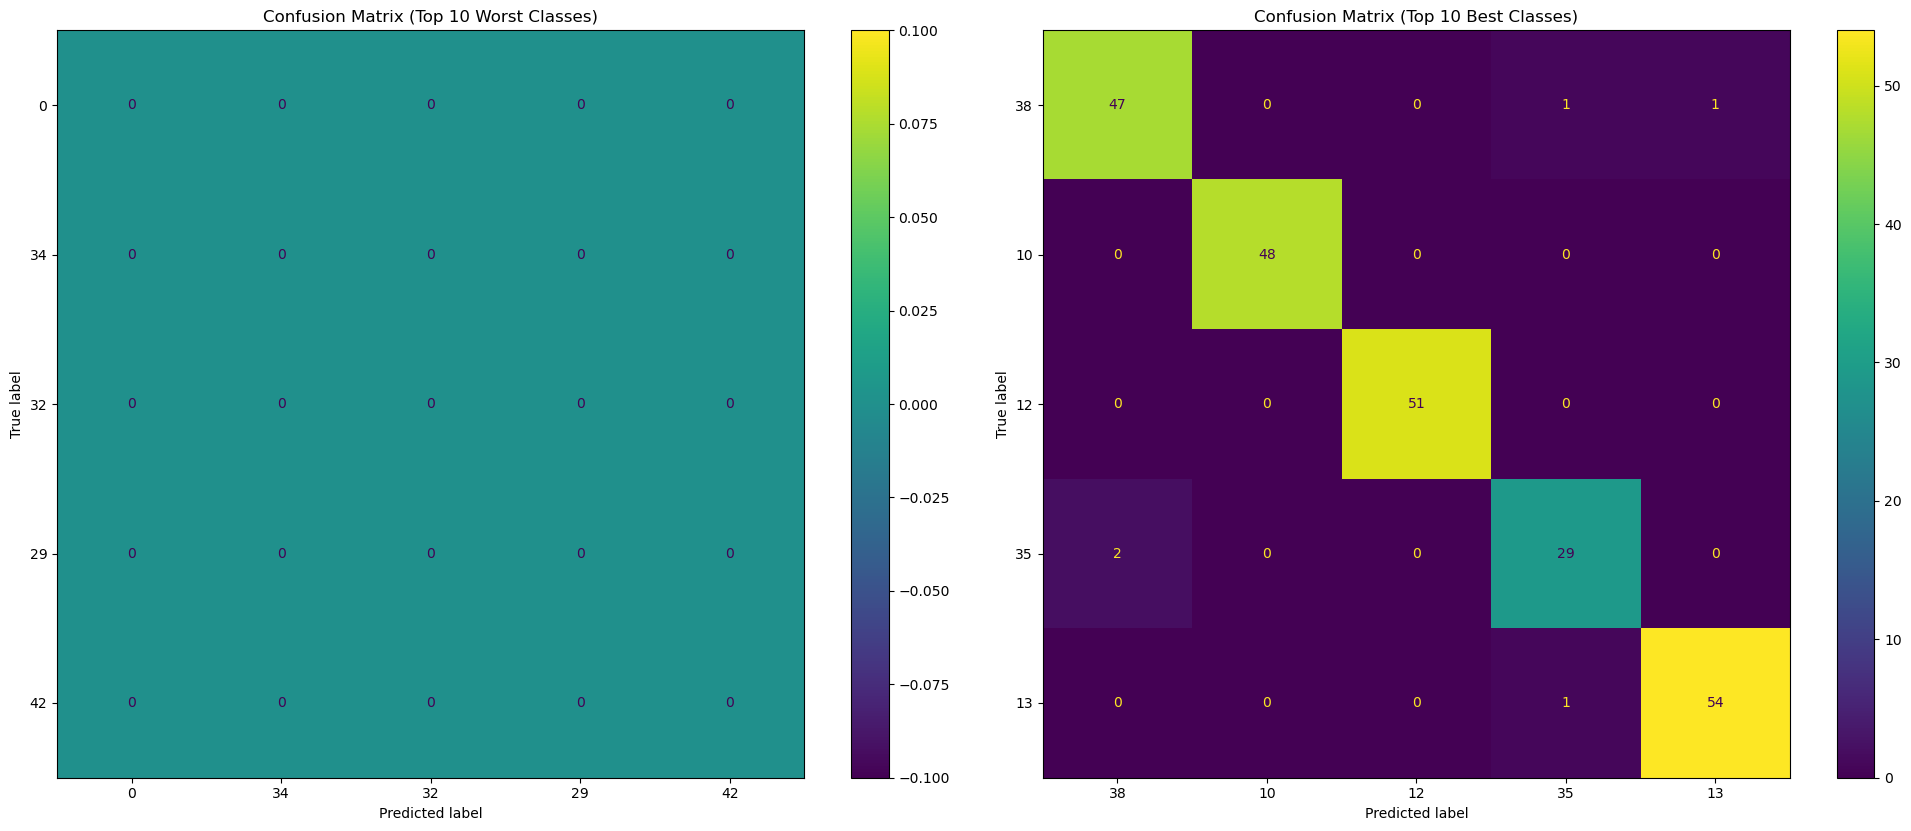

In [8]:
# Convert CArray to numpy to draw the confusion matrix
y_test_np = y_test.tondarray()
y_pred_np = y_pred.tondarray()

# Confusion Matrix
confs = confusion_matrix(y_test_np, y_pred_np)

#Graph
per_class_acc = confs.diagonal() / confs.sum(axis=1)


worst_idx = np.argsort(per_class_acc)[:5]   # Top 5 classes
best_idx = np.argsort(per_class_acc)[-5:]    # Worst 5 classes

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Worst 5
worst_confs = confs[np.ix_(worst_idx, worst_idx)]
ConfusionMatrixDisplay(confusion_matrix=worst_confs,
                       display_labels=worst_idx).plot(ax=axes[0], colorbar=True)
axes[0].set_title("Confusion Matrix (Top 10 Worst Classes)")

# Best 10
best_confs = confs[np.ix_(best_idx, best_idx)]
ConfusionMatrixDisplay(confusion_matrix=best_confs,
                       display_labels=best_idx).plot(ax=axes[1], colorbar=True)
axes[1].set_title("Confusion Matrix (Top 10 Best Classes)")

plt.tight_layout()
plt.show()

### Phase 3: Training-Time Attacks (Data Poisoning):

 **Poisoning Attack Implementation** 

Inject malicious samples into training data using one of: 

Label-flipping attacks 

Any of the clean-label backdoor attacks 

maintain attack budget (<15% training data contamination) 


**Poisoned Model Evaluation**

Retrain model on contaminated dataset 

Compare performance degradation on: 

Clean test set 

Poisoned validation samples 

Original validation set 

### Phase 4: Inference-Time Attacks (Adversarial Examples) 

Adversarial Attack Generation 

Implement two distinct attack methods: 

White-box: FGSM/PGD/C&W/DeepFool 

Black-box: Surrogate model 

Generate adversarial test sets with controlled perturbation budgets (ε ≤ 0.1) 

Attack Impact Analysis 

Quantify robustness drop using: 

Adversarial success rate 

Confidence score distributions 

Per-class vulnerability analysis 

### Phase 5: Comprehensive Evaluation 

Cross-Attack Susceptibility 

Test poisoned model against unseen attack vectors 

Analyze transferability between attack methods 

Vulnerability Report 

Create visualization: Security Curve for accuracy with both perturbations number and number of poisoned samples. 

Document failure modes and high-risk decision boundaries 